# Regime Modelling — Analysis Notebook

Implementing the Two Sigma GMM regime approach on Bloomberg + Fama-French data.

**References**
- *A Machine Learning Approach to Regime Modeling* — Two Sigma (2021)
- *Introducing the Two Sigma Factor Lens* — Two Sigma (2018)

## 0. Setup & imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Setup complete.')

Setup complete.


## 1. Configure data paths

Set `DATA_ROOT` to the folder containing `Bloomberg_Data/`, `Farma_French/`, `Macro/`.

In [2]:
from pathlib import Path

# ── CONFIGURE THIS ─────────────────────────────────────────────────────
DATA_ROOT = Path('.') / 'data'

# Patch the loader modules to use our DATA_ROOT
import data_loader as dl
dl.DATA_ROOT     = DATA_ROOT
dl.BLOOMBERG_DIR = DATA_ROOT / 'Bloomberg_Data'
dl.MACRO_DIR     = DATA_ROOT / 'Macro'
dl.FF_DIR        = DATA_ROOT / 'Farma_French'

for subdir in ['Bloomberg_Data', 'Farma_French', 'Macro']:
    p = DATA_ROOT / subdir
    print(f'  {subdir:20s}  {"OK" if p.exists() else "MISSING"}')

  Bloomberg_Data        OK
  Farma_French          OK
  Macro                 OK


## 2. Load & inspect raw data

In [3]:
from data_loader import (
    load_bloomberg_all, load_ff5_daily,
    load_interest_rate_daily, load_cpi_interest_rates,
    ALL_BLOOMBERG_TICKERS,
)

raw_panel = load_bloomberg_all(ALL_BLOOMBERG_TICKERS)
print(f'Raw Bloomberg panel: {raw_panel.shape}')
print()
for col in raw_panel.columns:
    s = raw_panel[col].dropna()
    print(f'  {col:12s}  {len(s):5d} obs  {s.index[0].date()} -> {s.index[-1].date()}')

Raw Bloomberg panel: (17077, 18)

  MXCXDMHR       6407 obs  1998-12-31 -> 2026-06-01
  LGY7TRUH       6550 obs  1987-06-30 -> 2026-06-01
  LUACTRUU       9582 obs  1973-01-31 -> 2026-06-01
  LF98TRUU       7167 obs  1983-07-29 -> 2026-06-01
  LP05TRUH       6568 obs  1999-01-29 -> 2026-06-01
  LP01TRUH       6600 obs  1999-01-29 -> 2026-06-01
  BCOMTR        16686 obs  1960-01-04 -> 2026-06-02
  MXEF          10023 obs  1987-12-31 -> 2026-06-01
  EMUSTRUU       7434 obs  1993-01-29 -> 2026-06-01
  BCIT5T         7632 obs  1997-02-28 -> 2026-06-01
  PUT           10055 obs  1986-06-30 -> 2026-06-01
  MXWD          10023 obs  1987-12-31 -> 2026-06-01
  LEGATRUU       7216 obs  1990-01-01 -> 2026-06-01
  RU30INTR      11962 obs  1978-12-29 -> 2026-06-01
  SPGSCITR      14219 obs  1970-01-02 -> 2026-06-01
  LBUSTRUU       9540 obs  1976-03-31 -> 2026-06-01
  JPEIGLBL       8100 obs  1993-12-31 -> 2026-06-01
  M1EF           6632 obs  2000-12-29 -> 2026-06-01


In [4]:
ff5 = load_ff5_daily()
ir  = load_interest_rate_daily()
cpi = load_cpi_interest_rates()
print(f'FF5 daily:           {ff5.shape}  {ff5.index[0].date()} -> {ff5.index[-1].date()}')
print(f'Interest Rate Daily: {ir.shape}')
print(f'CPI Quarterly:       {cpi.shape}')

FF5 daily:           (15813, 6)  1963-07-01 -> 2026-04-30
Interest Rate Daily: (25924, 82)
CPI Quarterly:       (397, 20)


## 3. Build clean data panel

Align all series to a business-day calendar, forward-fill gaps, compute log returns.

**Recommended start dates:**
- `2002-01-02` — all core Two Sigma factors available daily (default)
- `1999-01-04` — slightly earlier, swap MXCXDMHR for MXWD
- `1987-07-01` — longest history, monthly pre-daily data for some series

In [5]:
from data_cleaner import build_clean_dataset

START_DATE = '2002-01-02'

dataset  = build_clean_dataset(start=START_DATE)
prices   = dataset['prices']
returns  = dataset['returns']
ff5_aln  = dataset['ff5']
rf       = dataset['rf']
calendar = dataset['calendar']

print(f'Calendar:  {calendar[0].date()} -> {calendar[-1].date()}  ({len(calendar)} days)')
print(f'Prices:    {prices.shape}')
print(f'Returns:   {returns.shape}')
print(f'RF mean (daily): {rf.mean()*100:.5f}%')

Calendar:  2002-01-02 -> 2026-06-18  (6382 days)
Prices:    (6382, 18)
Returns:   (6374, 18)
RF mean (daily): 0.00712%


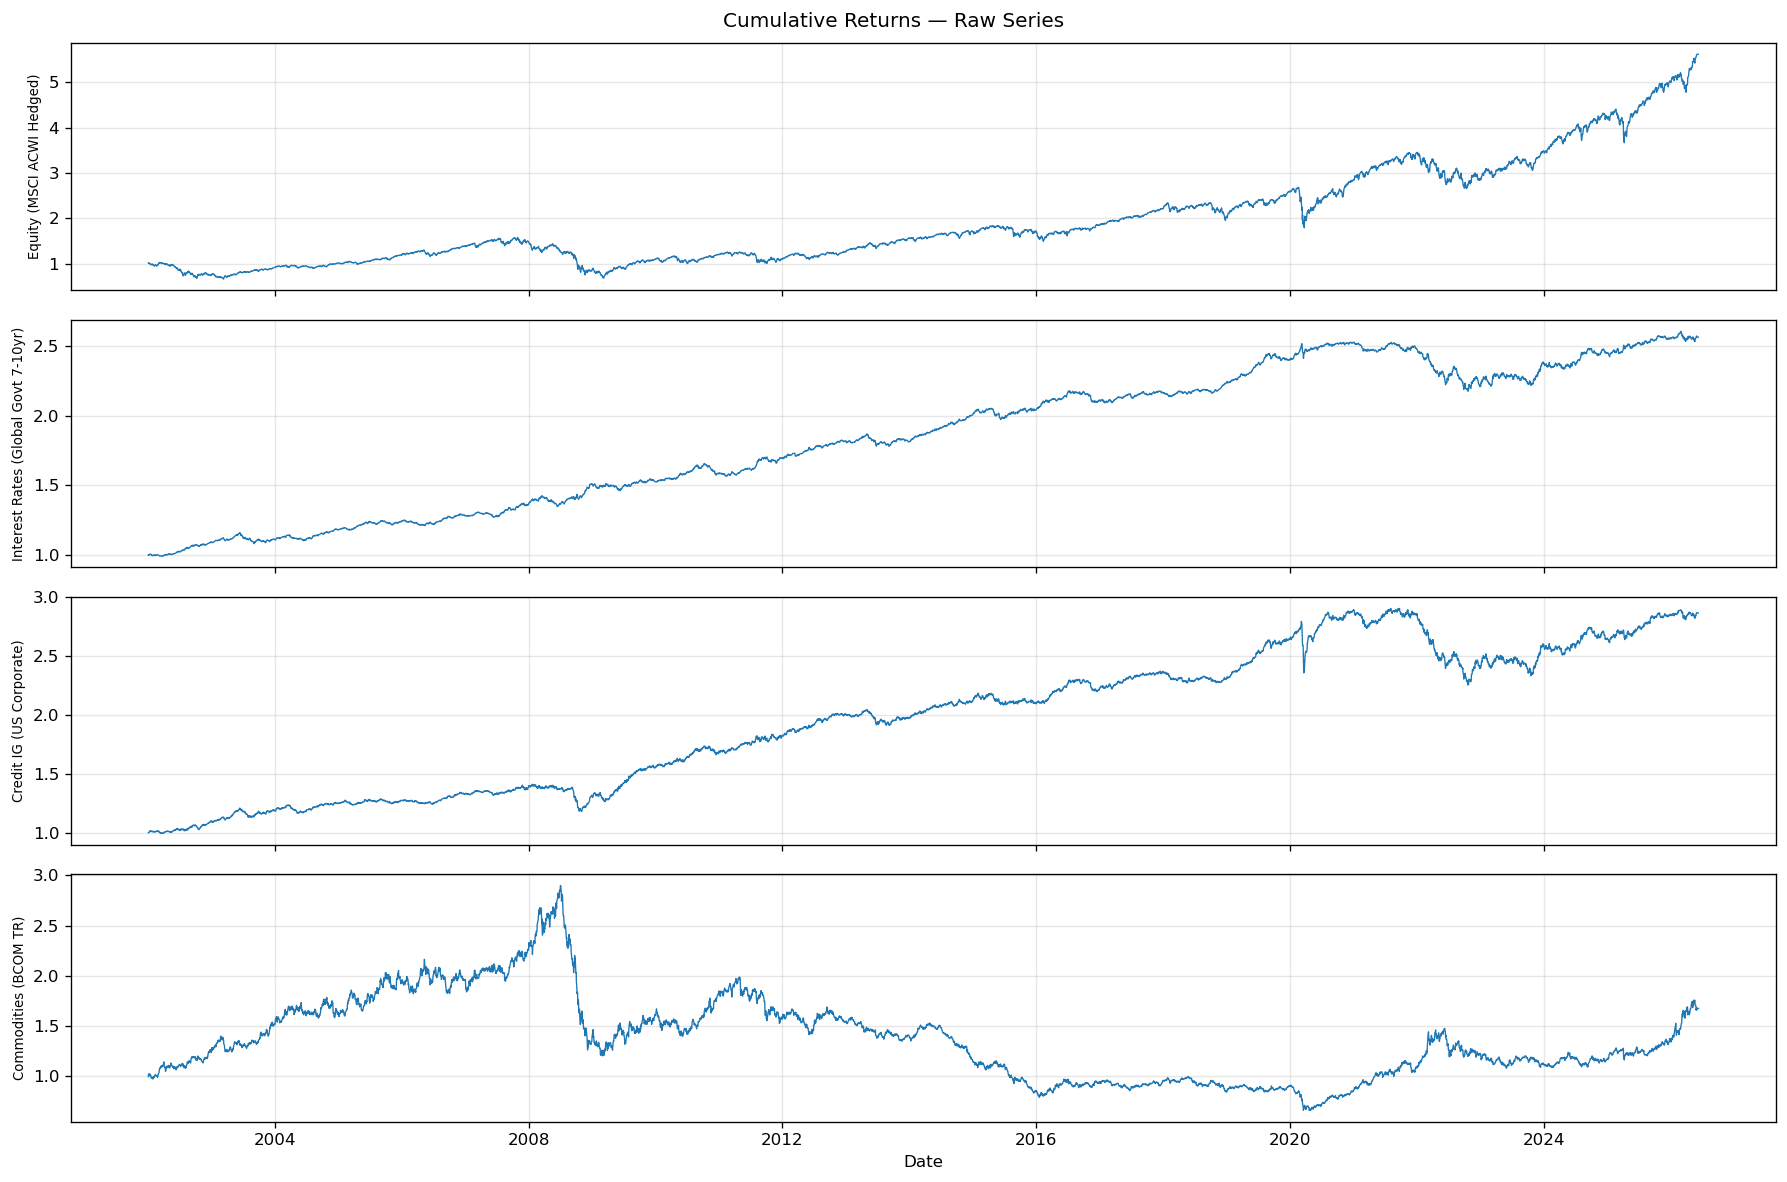

In [6]:
# Sanity-check: cumulative returns of raw series
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
checks = [
    ('MXCXDMHR', 'Equity (MSCI ACWI Hedged)'),
    ('LGY7TRUH', 'Interest Rates (Global Govt 7-10yr)'),
    ('LUACTRUU', 'Credit IG (US Corporate)'),
    ('BCOMTR',   'Commodities (BCOM TR)'),
]
for ax, (col, label) in zip(axes, checks):
    if col in returns.columns:
        cum = (1 + returns[col]).cumprod()
        ax.plot(cum.index, cum.values, linewidth=0.8)
        ax.set_ylabel(label, fontsize=8)
        ax.grid(alpha=0.3)
axes[-1].set_xlabel('Date')
fig.suptitle('Cumulative Returns — Raw Series', fontsize=12)
plt.tight_layout(); plt.show()

## 4. Construct factors

Build Core Macro → Secondary Macro → Style factors following the Two Sigma residualisation methodology (rolling EW-OLS, 60-day halflife).

In [7]:
from factor_construction import build_factor_matrix, get_factor_matrix_for_gmm

factor_matrix = build_factor_matrix(
    start=START_DATE,
    include_style=True,
    halflife_days=60,
    min_periods=126,
    verbose=True,
)

[factor_construction] Building factor matrix: 2002-01-02 → today
  Loading raw data...
  Returns panel: 6374 days × 18 series
  FF5 panel:     6382 days × 6 factors
  Building Core Macro factors (Equity, Rates, Credit, Commodities)...
[core_macro] Credit: 4 sub-indices (US IG, US HY, EU IG, EU HY) — EU legs active from mid-2000.
  Core Macro: all 4 factors valid from 2002-12-20
  Building Secondary Macro factors...
[secondary_macro] Foreign_Currency: built successfully.
  Secondary Macro columns: ['Emerging_Markets', 'Foreign_Currency', 'Local_Inflation', 'Short_Volatility', 'Trend_Following', 'Local_Equity']
  Building Style factors (FF5 residualised vs Core Macro)...
  Style columns: ['FF_Market', 'FF_SMB', 'FF_HML', 'FF_RMW', 'FF_CMA']
  After NA filtering (threshold=0.5): 5996 rows kept, 378 dropped
  Factor matrix shape: (5996, 15)
  Date range: 2003-06-16 -> 2026-06-08
  Columns: ['Equity', 'Interest_Rates', 'Credit', 'Commodities', 'Emerging_Markets', 'Foreign_Currency', 'Local_

In [8]:
print(f'Factor matrix: {factor_matrix.shape}')
print(f'Date range:    {factor_matrix.index[0].date()} -> {factor_matrix.index[-1].date()}')

# Annualised stats
ann_mean = factor_matrix.mean() * 252 * 100
ann_vol  = factor_matrix.std()  * (252**0.5) * 100
sharpe   = ann_mean / ann_vol
summary  = pd.DataFrame({'Mean_%': ann_mean, 'Vol_%': ann_vol, 'Sharpe': sharpe})
print(summary.round(3).to_string())

Factor matrix: (5996, 15)
Date range:    2003-06-16 -> 2026-06-08
                  Mean_%   Vol_%  Sharpe
Equity            9.2030 14.3130  0.6430
Interest_Rates    3.3770  3.2320  1.0450
Credit           -0.3750  2.3390 -0.1600
Commodities      -0.4160 14.8920 -0.0280
Emerging_Markets -0.8240  4.8050 -0.1710
Foreign_Currency -0.3240  6.4950 -0.0500
Local_Inflation   0.4980  4.7470  0.1050
Short_Volatility -1.0720  7.0900 -0.1510
Trend_Following   3.3040  4.5400  0.7280
Local_Equity     -0.1330  6.6300 -0.0200
FF_Market        -0.1580  6.8600 -0.0230
FF_SMB            0.1980  9.7100  0.0200
FF_HML           -0.9500 11.0560 -0.0860
FF_RMW            0.0050  6.9260  0.0010
FF_CMA           -0.1540  5.7420 -0.0270


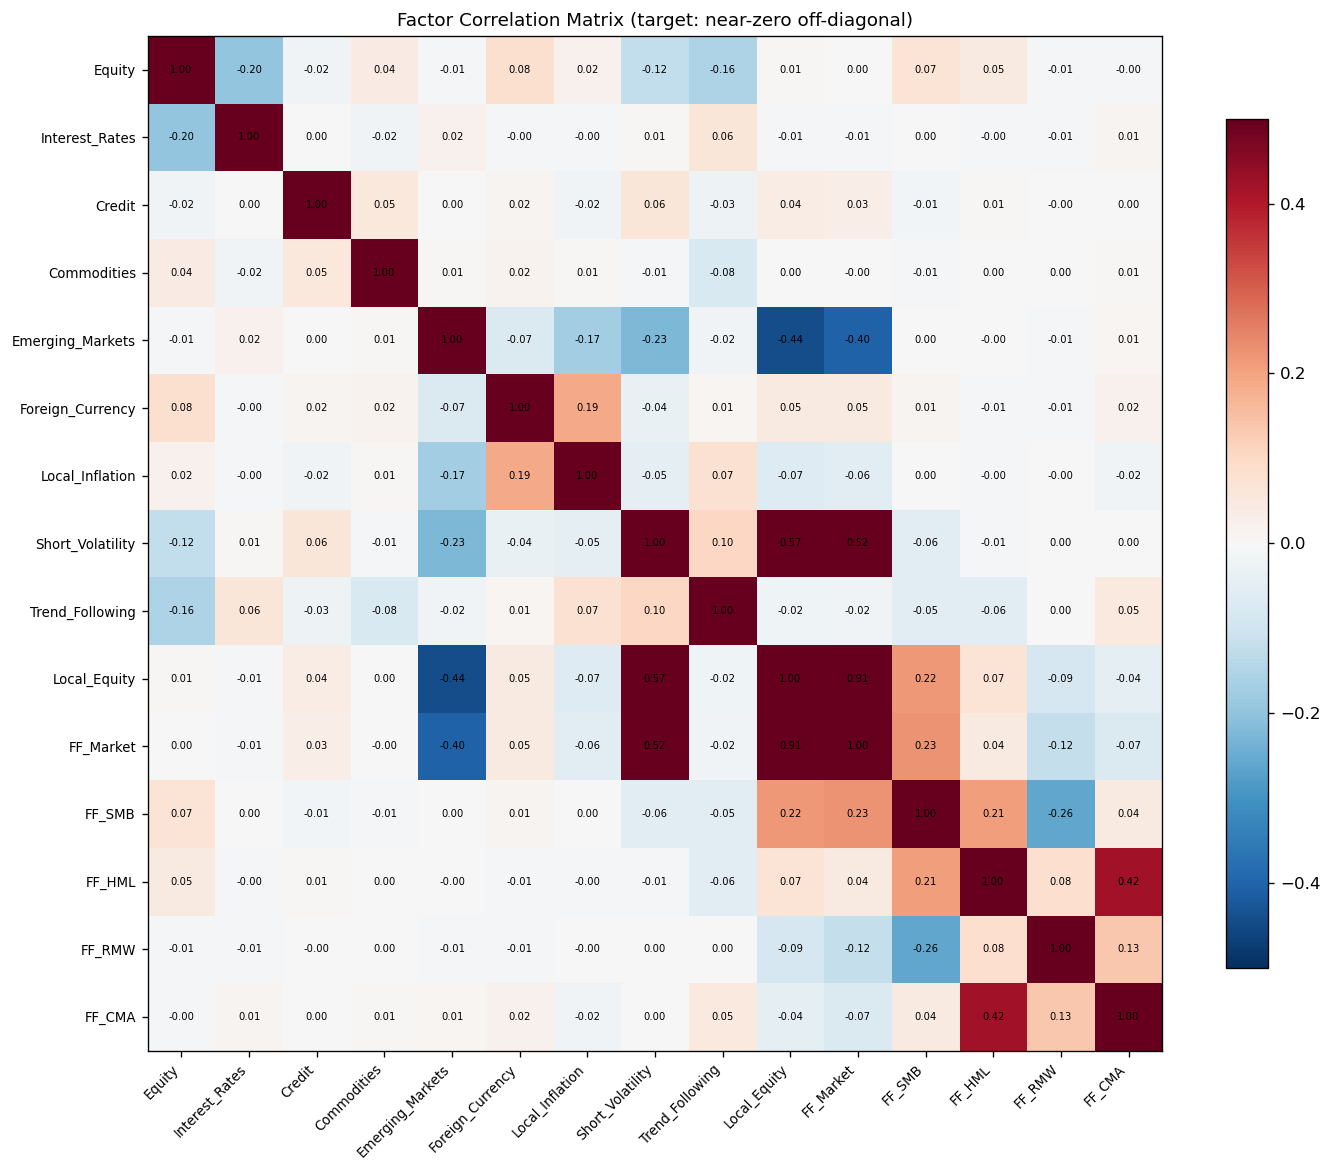

In [9]:
# Factor correlation matrix — should be near-zero (orthogonality check)
corr = factor_matrix.dropna().corr()
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=8)
ax.set_title('Factor Correlation Matrix (target: near-zero off-diagonal)', fontsize=11)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=6)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

## 5. Fit the GMM regime model

Cross-validated log-likelihood selects the optimal number of components.

In [10]:
from regime_model import fit_regime_model, predict_current_regime

# Drop any remaining NaN rows before GMM
X = get_factor_matrix_for_gmm(factor_matrix, dropna=True)
print(f'GMM input: {X.shape}  ({X.index[0].date()} -> {X.index[-1].date()})')

GMM input: (5974, 15)  (2003-06-16 -> 2026-05-07)


In [11]:
# Fit the GMM.  Set run_cv=False, n_components=4 to reproduce Two Sigma directly.
# With run_cv=True this takes ~3-8 minutes.
model = fit_regime_model(
    X,
    n_components=None,
    n_components_range=range(2, 7),
    n_init=20,
    cv_splits=5,
    run_cv=True,
    verbose=True,
)

[regime_model] Fitting GMM on 5974 obs × 15 factors
  Running 5-fold CV over n_components=[2, 3, 4, 5, 6]...
  n=2: mean CV log-likelihood = -17.6577
  n=3: mean CV log-likelihood = -17.2300
  n=4: mean CV log-likelihood = -16.7248
  n=5: mean CV log-likelihood = -16.5724
  n=6: mean CV log-likelihood = -16.4567
  Selected n_components = 6 (best CV log-lik = -16.4567)
  Fitting final GMM with n_components=6, n_init=20...
  GMM converged: True

  Annualised factor means per regime (%):
    Equity  Interest_Rates   Credit  Commodities  Emerging_Markets  Foreign_Currency  Local_Inflation  Short_Volatility  Trend_Following  Local_Equity  FF_Market  FF_SMB   FF_HML   FF_RMW   FF_CMA
0 -11.6500         12.4600 -42.8100     -76.3900          -15.4200           -7.1600          16.1500          -14.6300           9.7000        1.6600    49.1400 54.0200  10.2400 -14.4100 -29.0200
1   1.1400          5.6800  -4.2100       3.3800           -5.2700           -0.9300           2.7900            6.7

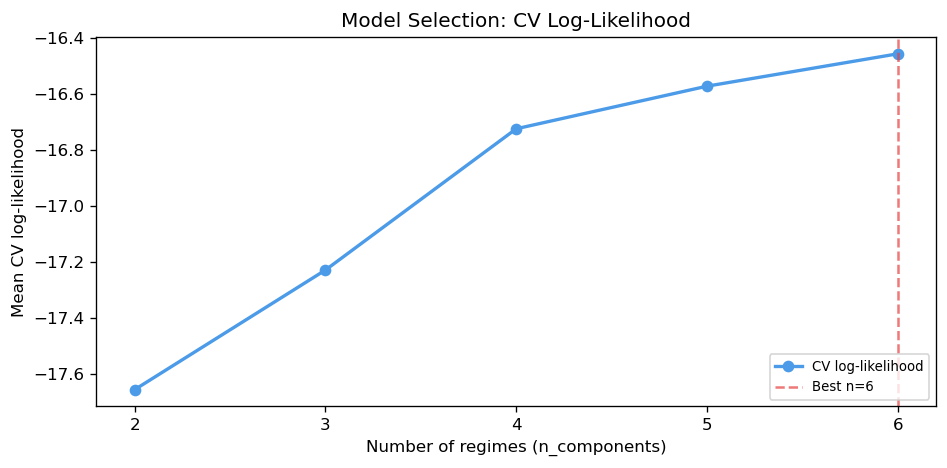

Selected n_components = 6


In [12]:
from regime_utils import plot_cv_scores
if model.cv_scores:
    fig = plot_cv_scores(model.cv_scores)
    plt.show()
print(f'Selected n_components = {model.n_components}')

## 6. Interpret and label regimes

Inspect factor means per cluster. The auto-labeller applies Two Sigma heuristics; override with `relabel_regimes()` if needed.

In [13]:
from regime_utils import compute_regime_stats, plot_factor_heatmap, relabel_regimes

means_df, vols_df = compute_regime_stats(factor_matrix, model.hard_labels, model.regime_names)

print('Auto-assigned labels:', model.regime_names)
print()
print('Annualised factor means by regime (%):')
print((means_df * 100).round(2).to_string())

IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

In [ ]:
fig = plot_factor_heatmap(means_df, vols_df,
    title='Annualised Factor Mean Returns by Regime (%)')
plt.show()

In [ ]:
# Override labels if the auto-labeller got any wrong.
# Inspect the heatmap above and the means table, then set indices accordingly.
#
# Example:
# model = relabel_regimes(model, {
#     0: 'Crisis',
#     1: 'Steady_State',
#     2: 'Inflation',
#     3: 'WOI',
# })
print('Current labels:', model.regime_names)

## 7. Historical regime analysis

In [ ]:
from regime_utils import plot_regime_timeline, plot_regime_probabilities, get_regime_periods

fig = plot_regime_timeline(model.hard_labels, model.regime_names,
    title='Regime Classification History', figsize=(16, 2.5))
plt.show()

In [ ]:
fig = plot_regime_probabilities(model.probabilities, model.regime_names,
    title='Regime Probabilities Over Time', figsize=(16, 4))
plt.show()

In [ ]:
freq = model.hard_labels.value_counts().sort_index()
print('Regime frequency:')
for k, cnt in freq.items():
    pct = 100 * cnt / len(model.hard_labels)
    label = model.regime_names.get(k, f'Regime_{k}')
    print(f'  {label:15s}  {cnt:5d} days  ({pct:.1f}%)')

## 8. Transition matrix

In [ ]:
from regime_utils import compute_transition_matrix

trans = compute_transition_matrix(model.hard_labels, model.regime_names)
print('Regime transition probabilities (%):')
print((trans * 100).round(1).to_string())

## 9. Current regime — "Where are we now?"

In [ ]:
current = predict_current_regime(model, X, window_days=60)
print('Current regime probabilities (last 60 days):')
print(current.sort_values(ascending=False).to_string())

recent = factor_matrix.tail(252).mean() * 252 * 100
print()
print('Factor returns (ann. %, trailing 1yr):')
print(recent.sort_values(ascending=False).round(2).to_string())

## 10. Full dashboard

In [ ]:
from regime_utils import plot_dashboard
fig = plot_dashboard(model, factor_matrix, figsize=(18, 14))
plt.show()

## 11. Walk-forward stability (optional — slow)

Re-fits the GMM on rolling 5-year windows to check regime-label consistency.

In [ ]:
# from regime_utils import rolling_regime_window
#
# rolling_probs = rolling_regime_window(
#     X, n_components=model.n_components,
#     train_years=5, step_months=3, n_init=10, verbose=True,
# )
# rolling_probs.to_parquet('outputs/rolling_regime_probs.parquet')
print('Uncomment the block above to run walk-forward analysis.')

## 12. Save outputs

In [ ]:
import os
os.makedirs('outputs', exist_ok=True)

factor_matrix.to_parquet('outputs/factor_matrix.parquet')
model.probabilities.to_parquet('outputs/regime_probabilities.parquet')
model.hard_labels.map(model.regime_names).to_frame('regime').to_parquet('outputs/regime_labels.parquet')
means_df.to_csv('outputs/regime_factor_means.csv')
vols_df.to_csv('outputs/regime_factor_vols.csv')
print('Outputs saved to outputs/')

## Next steps

- **Trading**: use `model.probabilities` as soft signals for regime-conditional position sizing.
- **Extended history**: set `START_DATE = '1987-07-01'` for monthly pre-daily data.
- **Foreign Currency factor**: add G10 FX spot rates to enable the full Two Sigma lens.
- **Walk-forward**: uncomment Section 11 and cache the rolling probabilities.